# 🔹 CLR(1) Parser — Canonical LR Parser

A **CLR(1) Parser (Canonical LR(1) Parser)** is a bottom-up, shift-reduce parser used in **Compiler Design** to parse context-free grammars. It uses **LR(1) items**, where each item contains a production with a dot position and a **one-symbol lookahead**.

In this notebook, we implement the process of constructing a **CLR(1) parsing table** programmatically, including the generation of LR(1) items, `closure`, `goto`, and the **ACTION/GOTO parsing table**.

### ⚙️ What This Notebook Does

* 📐 Defines a context-free grammar
* 🔧 Creates the augmented grammar
* 🔍 Generates LR(1) items
* 🧩 Calculates `closure`
* ➡️ Calculates `goto`
* 🗂️ Constructs the canonical collection of LR(1) items
* 📊 Generates the CLR(1) parsing table
* 🧮 Represents the parsing table using tables/data structures
* 🔄 Uses the generated table to perform parsing

> **📝 Important:** The **grammar section in the code is customizable**.
> Update the grammar productions according to the grammar you want to parse before running the parser.

---

### 👨‍💻 Author

**Muhammad Ali**

[![GitHub](https://img.shields.io/badge/GitHub-AliMuhammad78-181717?style=flat-square\&logo=github\&logoColor=white)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Muhammad%20Ali-0A66C2?style=flat-square\&logo=linkedin\&logoColor=white)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-ali98muhammad45-20BEFF?style=flat-square\&logo=kaggle\&logoColor=white)](https://www.kaggle.com/ali98muhammad45)


In [5]:
from collections import defaultdict, deque

# ==============================
# DEFINE GRAMMAR HERE
# ==============================

grammar = {
    "S": ["A", "Bb"],
    "A": ["aAb", "0"],
    "B": ["aBbb", "1"]
}

start_symbol = "S"

# ==============================
# AUGMENT GRAMMAR
# ==============================

augmented_start = start_symbol + "'"
grammar[augmented_start] = [start_symbol]

non_terminals = set(grammar.keys())

terminals = set()
for lhs in grammar:
    for prod in grammar[lhs]:
        for ch in prod:
            if ch not in non_terminals:
                terminals.add(ch)

terminals.add('$')

# ==============================
# FIRST SETS
# ==============================

FIRST = defaultdict(set)

for t in terminals:
    FIRST[t].add(t)

changed = True

while changed:
    changed = False

    for A in grammar:
        for prod in grammar[A]:

            nullable = True

            for symbol in prod:

                before = len(FIRST[A])

                FIRST[A].update(FIRST[symbol] - {'ε'})

                if len(FIRST[A]) > before:
                    changed = True

                if 'ε' not in FIRST[symbol]:
                    nullable = False
                    break

            if nullable:
                if 'ε' not in FIRST[A]:
                    FIRST[A].add('ε')
                    changed = True


def first_string(string):
    result = set()

    for symbol in string:
        result.update(FIRST[symbol] - {'ε'})

        if 'ε' not in FIRST[symbol]:
            return result

    result.add('ε')
    return result


# ==============================
# LR(1) ITEM
# (A -> α . β , a)
# ==============================

def closure(items):

    closure_set = set(items)

    changed = True

    while changed:
        changed = False

        new_items = set()

        for lhs, rhs, dot, lookahead in closure_set:

            if dot < len(rhs):

                B = rhs[dot]

                if B in non_terminals:

                    beta = rhs[dot + 1:]

                    first_beta_a = first_string(beta + lookahead)

                    for production in grammar[B]:
                        for b in first_beta_a:

                            item = (B, production, 0, b)

                            if item not in closure_set:
                                new_items.add(item)

        if new_items:
            closure_set.update(new_items)
            changed = True

    return frozenset(closure_set)


def goto(items, symbol):

    moved = set()

    for lhs, rhs, dot, lookahead in items:

        if dot < len(rhs) and rhs[dot] == symbol:
            moved.add((lhs, rhs, dot + 1, lookahead))

    return closure(moved) if moved else frozenset()


# ==============================
# CANONICAL COLLECTION
# ==============================

I0 = closure({
    (augmented_start, start_symbol, 0, '$')
})

states = [I0]
state_map = {I0: 0}

transitions = {}

queue = deque([I0])

while queue:

    I = queue.popleft()
    i = state_map[I]

    symbols = terminals | non_terminals

    for X in symbols:

        J = goto(I, X)

        if not J:
            continue

        if J not in state_map:
            state_map[J] = len(states)
            states.append(J)
            queue.append(J)

        transitions[(i, X)] = state_map[J]

# ==============================
# PRINT CLR(1) STATES
# ==============================

print("\nCANONICAL LR(1) ITEM SETS\n")

for index, state in enumerate(states):

    print(f"I{index}:")

    for lhs, rhs, dot, lookahead in sorted(state):

        rhs_with_dot = rhs[:dot] + "." + rhs[dot:]

        print(
            f"   {lhs} -> {rhs_with_dot} , {lookahead}"
        )

    print()

# ==============================
# BUILD ACTION / GOTO TABLE
# ==============================

ACTION = defaultdict(dict)
GOTO = defaultdict(dict)

for i, state in enumerate(states):

    for lhs, rhs, dot, lookahead in state:

        # Shift

        if dot < len(rhs):

            symbol = rhs[dot]

            if symbol in terminals:

                j = transitions.get((i, symbol))

                if j is not None:
                    ACTION[i][symbol] = f"s{j}"

        # Reduce / Accept

        else:

            if lhs == augmented_start:
                ACTION[i]['$'] = "acc"

            else:
                ACTION[i][lookahead] = f"r({lhs}->{rhs})"

    # GOTO

    for nt in non_terminals:

        j = transitions.get((i, nt))

        if j is not None:
            GOTO[i][nt] = j

# ==============================
# PRINT PARSING TABLE
# ==============================

print("\nCLR(1) PARSING TABLE\n")

terminals_list = sorted(terminals)
non_terminals_list = sorted(
    [x for x in non_terminals if x != augmented_start]
)

header = (
    ["State"]
    + terminals_list
    + non_terminals_list
)

print("{:<8}".format("State"), end="")

for h in header[1:]:
    print("{:<15}".format(h), end="")

print()

for state in range(len(states)):

    print("{:<8}".format(state), end="")

    for t in terminals_list:
        print(
            "{:<15}".format(
                ACTION[state].get(t, "")
            ),
            end=""
        )

    for nt in non_terminals_list:
        print(
            "{:<15}".format(
                str(GOTO[state].get(nt, ""))
            ),
            end=""
        )

    print()


CANONICAL LR(1) ITEM SETS

I0:
   A -> .0 , $
   A -> .aAb , $
   B -> .1 , b
   B -> .aBbb , b
   S -> .A , $
   S -> .Bb , $
   S' -> .S , $

I1:
   S' -> S. , $

I2:
   A -> .0 , b
   A -> .aAb , b
   A -> a.Ab , $
   B -> .1 , b
   B -> .aBbb , b
   B -> a.Bbb , b

I3:
   S -> B.b , $

I4:
   S -> A. , $

I5:
   A -> 0. , $

I6:
   B -> 1. , b

I7:
   A -> .0 , b
   A -> .aAb , b
   A -> a.Ab , b
   B -> .1 , b
   B -> .aBbb , b
   B -> a.Bbb , b

I8:
   B -> aB.bb , b

I9:
   A -> aA.b , $

I10:
   A -> 0. , b

I11:
   S -> Bb. , $

I12:
   A -> aA.b , b

I13:
   B -> aBb.b , b

I14:
   A -> aAb. , $

I15:
   A -> aAb. , b

I16:
   B -> aBbb. , b


CLR(1) PARSING TABLE

State   $              0              1              a              b              A              B              S              
0                      s5             s6             s2                            4              3              1              
1       acc                                              

---

---

CLR(1) CANONICAL COLLECTION

I0
A -> •0 , $
A -> •aAb , $
B -> •1 , b
B -> •aBbb , b
S -> •A , $
S -> •Bb , $
S' -> •S , $

I1
S' -> S• , $

I2
A -> •0 , b
A -> •aAb , b
A -> a•Ab , $
B -> •1 , b
B -> •aBbb , b
B -> a•Bbb , b

I3
S -> B•b , $

I4
S -> A• , $

I5
A -> 0• , $

I6
B -> 1• , b

I7
A -> •0 , b
A -> •aAb , b
A -> a•Ab , b
B -> •1 , b
B -> •aBbb , b
B -> a•Bbb , b

I8
B -> aB•bb , b

I9
A -> aA•b , $

I10
A -> 0• , b

I11
S -> Bb• , $

I12
A -> aA•b , b

I13
B -> aBb•b , b

I14
A -> aAb• , $

I15
A -> aAb• , b

I16
B -> aBbb• , b

DFA Diagram Saved: CLR1_DFA.png


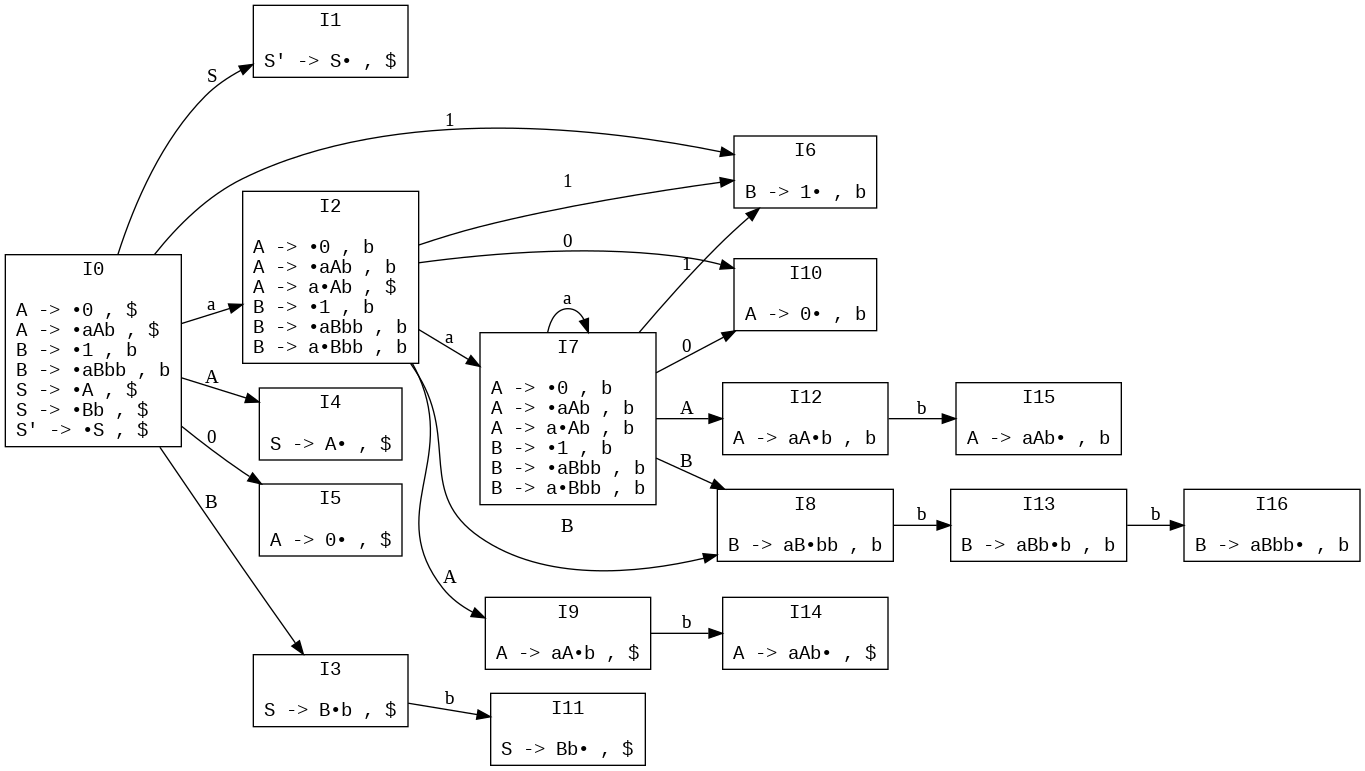



CLR(1) PARSING TABLE
State   $              0              1              a              b              A              B              S              
0                      s5             s6             s2                            4              3              1              
1       acc                                                                                                                     
2                      s10            s6             s7                            9              8                             
3                                                                   s11                                                         
4       r(S->A)                                                                                                                 
5       r(A->0)                                                                                                                 
6                                                                   r(B->1

In [6]:
# Install graphviz in Colab (run once)
!apt-get -qq install graphviz
!pip -q install graphviz

from collections import defaultdict, deque
from graphviz import Digraph
from IPython.display import Image, display

# =====================================================
# GRAMMAR
# =====================================================

grammar = {
    "S": ["A", "Bb"],
    "A": ["aAb", "0"],
    "B": ["aBbb", "1"]
}

start_symbol = "S"

# =====================================================
# AUGMENT GRAMMAR
# =====================================================

augmented_start = start_symbol + "'"
grammar[augmented_start] = [start_symbol]

non_terminals = set(grammar.keys())

terminals = set()

for lhs in grammar:
    for prod in grammar[lhs]:
        for ch in prod:
            if ch not in non_terminals:
                terminals.add(ch)

terminals.add('$')

# =====================================================
# FIRST SETS
# =====================================================

FIRST = defaultdict(set)

for t in terminals:
    FIRST[t].add(t)

changed = True

while changed:

    changed = False

    for A in grammar:

        for prod in grammar[A]:

            nullable = True

            for symbol in prod:

                before = len(FIRST[A])

                FIRST[A].update(FIRST[symbol] - {'ε'})

                if len(FIRST[A]) > before:
                    changed = True

                if 'ε' not in FIRST[symbol]:
                    nullable = False
                    break

            if nullable:

                if 'ε' not in FIRST[A]:
                    FIRST[A].add('ε')
                    changed = True


def first_string(string):

    result = set()

    for symbol in string:

        result.update(FIRST[symbol] - {'ε'})

        if 'ε' not in FIRST[symbol]:
            return result

    result.add('ε')
    return result


# =====================================================
# CLOSURE
# =====================================================

def closure(items):

    closure_set = set(items)

    changed = True

    while changed:

        changed = False
        new_items = set()

        for lhs, rhs, dot, lookahead in closure_set:

            if dot < len(rhs):

                B = rhs[dot]

                if B in non_terminals:

                    beta = rhs[dot + 1:]

                    first_beta_a = first_string(beta + lookahead)

                    for production in grammar[B]:

                        for b in first_beta_a:

                            item = (
                                B,
                                production,
                                0,
                                b
                            )

                            if item not in closure_set:
                                new_items.add(item)

        if new_items:

            closure_set.update(new_items)
            changed = True

    return frozenset(closure_set)


# =====================================================
# GOTO
# =====================================================

def goto(items, symbol):

    moved = set()

    for lhs, rhs, dot, lookahead in items:

        if dot < len(rhs) and rhs[dot] == symbol:

            moved.add(
                (
                    lhs,
                    rhs,
                    dot + 1,
                    lookahead
                )
            )

    if moved:
        return closure(moved)

    return frozenset()


# =====================================================
# CANONICAL LR(1) COLLECTION
# =====================================================

I0 = closure({
    (augmented_start, start_symbol, 0, '$')
})

states = [I0]

state_map = {
    I0: 0
}

transitions = {}

queue = deque([I0])

while queue:

    I = queue.popleft()

    i = state_map[I]

    symbols = terminals | non_terminals

    for X in symbols:

        J = goto(I, X)

        if not J:
            continue

        if J not in state_map:

            state_map[J] = len(states)

            states.append(J)

            queue.append(J)

        transitions[(i, X)] = state_map[J]

# =====================================================
# PRINT STATES
# =====================================================

print("=" * 70)
print("CLR(1) CANONICAL COLLECTION")
print("=" * 70)

for idx, state in enumerate(states):

    print(f"\nI{idx}")

    for lhs, rhs, dot, lookahead in sorted(state):

        rhs_dot = rhs[:dot] + "•" + rhs[dot:]

        print(
            f"{lhs} -> {rhs_dot} , {lookahead}"
        )

# =====================================================
# DRAW DFA
# =====================================================

dot = Digraph("CLR1_DFA")

dot.attr(rankdir="LR")

for idx, state in enumerate(states):

    label = f"I{idx}\\n\\n"

    for lhs, rhs, dot_pos, lookahead in sorted(state):

        rhs_dot = rhs[:dot_pos] + "•" + rhs[dot_pos:]

        label += (
            f"{lhs} -> {rhs_dot} , {lookahead}\\l"
        )

    dot.node(
        str(idx),
        label,
        shape="box",
        fontname="Courier"
    )

for (src, symbol), dst in transitions.items():

    dot.edge(
        str(src),
        str(dst),
        label=symbol
    )

dot.render(
    "CLR1_DFA",
    format="png",
    cleanup=True
)

print("\nDFA Diagram Saved: CLR1_DFA.png")

display(Image("CLR1_DFA.png"))

# =====================================================
# BUILD ACTION / GOTO TABLE
# =====================================================

ACTION = defaultdict(dict)
GOTO = defaultdict(dict)

for i, state in enumerate(states):

    for lhs, rhs, dot, lookahead in state:

        if dot < len(rhs):

            symbol = rhs[dot]

            if symbol in terminals:

                j = transitions.get((i, symbol))

                if j is not None:
                    ACTION[i][symbol] = f"s{j}"

        else:

            if lhs == augmented_start:

                ACTION[i]['$'] = "acc"

            else:

                ACTION[i][lookahead] = (
                    f"r({lhs}->{rhs})"
                )

    for nt in non_terminals:

        j = transitions.get((i, nt))

        if j is not None:
            GOTO[i][nt] = j

# =====================================================
# PRINT CLR(1) TABLE
# =====================================================

print("\n")
print("=" * 70)
print("CLR(1) PARSING TABLE")
print("=" * 70)

terminals_list = sorted(terminals)

non_terminals_list = sorted(
    [x for x in non_terminals
     if x != augmented_start]
)

print("{:<8}".format("State"), end="")

for t in terminals_list:
    print("{:<15}".format(t), end="")

for nt in non_terminals_list:
    print("{:<15}".format(nt), end="")

print()

for state in range(len(states)):

    print("{:<8}".format(state), end="")

    for t in terminals_list:

        print(
            "{:<15}".format(
                ACTION[state].get(t, "")
            ),
            end=""
        )

    for nt in non_terminals_list:

        print(
            "{:<15}".format(
                str(GOTO[state].get(nt, ""))
            ),
            end=""
        )

    print()

---
---
---
---
---

In [7]:
# ==========================================================
# LALR(1) CONSTRUCTION FROM CLR(1) STATES
# ==========================================================

from collections import defaultdict

# --------------------------
# LR(0) CORE
# --------------------------

def core(state):
    return frozenset(
        (lhs, rhs, dot)
        for lhs, rhs, dot, lookahead in state
    )

# --------------------------
# GROUP STATES BY CORE
# --------------------------

core_map = defaultdict(list)

for state_id, state in enumerate(states):
    core_map[core(state)].append(state_id)

# --------------------------
# BUILD MERGED LALR STATES
# --------------------------

lalr_states = []
old_to_new = {}

for new_id, group in enumerate(core_map.values()):

    merged_items = defaultdict(set)

    for old_state in group:

        for lhs, rhs, dot, lookahead in states[old_state]:

            merged_items[
                (lhs, rhs, dot)
            ].add(lookahead)

    merged_state = set()

    for (lhs, rhs, dot), lookaheads in merged_items.items():

        for la in lookaheads:

            merged_state.add(
                (lhs, rhs, dot, la)
            )

    lalr_states.append(
        frozenset(merged_state)
    )

    for old_state in group:
        old_to_new[old_state] = new_id

# --------------------------
# BUILD LALR TRANSITIONS
# --------------------------

lalr_transitions = {}

for (old_src, symbol), old_dst in transitions.items():

    new_src = old_to_new[old_src]
    new_dst = old_to_new[old_dst]

    lalr_transitions[
        (new_src, symbol)
    ] = new_dst

# --------------------------
# BUILD ACTION / GOTO TABLE
# --------------------------

ACTION = defaultdict(dict)
GOTO = defaultdict(dict)

conflicts = []

for state_no, state in enumerate(lalr_states):

    for lhs, rhs, dot, lookahead in state:

        # SHIFT

        if dot < len(rhs):

            symbol = rhs[dot]

            if symbol in terminals:

                target = lalr_transitions.get(
                    (state_no, symbol)
                )

                if target is not None:

                    action = f"s{target}"

                    if (
                        symbol in ACTION[state_no]
                        and ACTION[state_no][symbol] != action
                    ):
                        conflicts.append(
                            (
                                state_no,
                                symbol,
                                ACTION[state_no][symbol],
                                action
                            )
                        )

                    ACTION[state_no][symbol] = action

        # REDUCE / ACCEPT

        else:

            if lhs == augmented_start:

                action = "acc"

                if (
                    '$' in ACTION[state_no]
                    and ACTION[state_no]['$'] != action
                ):
                    conflicts.append(
                        (
                            state_no,
                            '$',
                            ACTION[state_no]['$'],
                            action
                        )
                    )

                ACTION[state_no]['$'] = action

            else:

                action = f"r({lhs}->{rhs})"

                if (
                    lookahead in ACTION[state_no]
                    and ACTION[state_no][lookahead] != action
                ):
                    conflicts.append(
                        (
                            state_no,
                            lookahead,
                            ACTION[state_no][lookahead],
                            action
                        )
                    )

                ACTION[state_no][lookahead] = action

    # GOTO

    for nt in non_terminals:

        target = lalr_transitions.get(
            (state_no, nt)
        )

        if target is not None:
            GOTO[state_no][nt] = target

# ==========================================================
# PRINT CONFLICTS
# ==========================================================

print("\n" + "=" * 70)
print("LALR(1) CONFLICT REPORT")
print("=" * 70)

if not conflicts:

    print("No conflicts found.")

else:

    for state, symbol, old, new in conflicts:

        print(
            f"State {state}, Symbol '{symbol}'"
        )

        print(
            f"Conflict: {old}  <->  {new}"
        )

        print()

# ==========================================================
# PRINT LALR TABLE
# ==========================================================

print("\n" + "=" * 70)
print("LALR(1) PARSING TABLE")
print("=" * 70)

terminals_list = sorted(terminals)

non_terminals_list = sorted(
    [
        nt
        for nt in non_terminals
        if nt != augmented_start
    ]
)

print("{:<8}".format("State"), end="")

for t in terminals_list:
    print("{:<15}".format(t), end="")

for nt in non_terminals_list:
    print("{:<15}".format(nt), end="")

print()

for state in range(len(lalr_states)):

    print("{:<8}".format(state), end="")

    for t in terminals_list:

        print(
            "{:<15}".format(
                ACTION[state].get(t, "")
            ),
            end=""
        )

    for nt in non_terminals_list:

        print(
            "{:<15}".format(
                str(
                    GOTO[state].get(nt, "")
                )
            ),
            end=""
        )

    print()

# ==========================================================
# SUMMARY
# ==========================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("CLR States  :", len(states))
print("LALR States :", len(lalr_states))
print("Conflicts   :", len(conflicts))


LALR(1) CONFLICT REPORT
No conflicts found.

LALR(1) PARSING TABLE
State   $              0              1              a              b              A              B              S              
0                      s5             s6             s2                            4              3              1              
1       acc                                                                                                                     
2                      s5             s6             s2                            8              7                             
3                                                                   s9                                                          
4       r(S->A)                                                                                                                 
5       r(A->0)                                                     r(A->0)                                                     
6                            